## Part 1 - Importing the libraries

In [ ]:
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(6)
tf.config.threading.set_inter_op_parallelism_threads(6)

import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Part 2 - Data Preprocessing
### Step 1 : Load Dataset

In [2]:
# load the data
with open("sample_data_interview_task.pickle", "rb") as f:
    (train_race_ids, train_df, train_timelines), (test_race_ids, test_df, test_timelines) = pickle.load(f)

# train_df is sample_data_interview_task_train.csv
# test_df is sample_data_interview_task_test.csv

# focus on just the flat races
train_df = train_df[train_df.pa_race_type_string == "Flat"]
_race_ids = train_df.race_id.unique()
train_timelines = [ x for race_id, x in zip(train_race_ids, train_timelines)
    if race_id in _race_ids ]
train_race_ids = [ x for x in train_race_ids
    if x in _race_ids ]

test_df = test_df[test_df.pa_race_type_string == "Flat"]
_race_ids = test_df.race_id.unique()
test_timelines = [ x for race_id, x in zip(test_race_ids, test_timelines)
    if race_id in _race_ids ]
test_race_ids = [ x for x in test_race_ids 
    if x in _race_ids ]

### dataframe columns

| Field                          | Description                                                                                     |
|-------------------------------|-------------------------------------------------------------------------------------------------|
| V                             | Instantaneous runner speed                                                                      |
| P                             | Instantaneous runner distance remaining to finish line                                          |
| SF                            | Instantaneous runner stride frequency (can be a bit noisy, especially if strides are missed)    |
| start_timestamp               | Start timestamp of the race                                                                     |
| finish_timestamp              | Finish timestamp of the race when first runner crosses the finish line                         |
| timestamp                     | Current timestamp                                                                               |
| timestamp_float               | Same as `.timestamp()`                                                                          |
| race_id                       | Race ID                                                                                         |
| weighted_average_v            | Runner weighted (more recent timestamps weighted higher) average speed over previous 5s         |
| weighted_average_sf           | Runner weighted average stride frequency over previous 10s                                      |
| weighted_average_v_t-1        | Runner weighted average speed at the previous timestamp                                         |
| previous_instantaneous_v      | Runner instantaneous speed at the previous timestamp                                            |
| weighted_average_acceleration | Runner acceleration based on weighted average speed change                                      |
| acceleration                  | Runner instantaneous acceleration based on instantaneous speed change                           |
| gmax_racecourse_name          | Racecourse name                                                                                 |
| gmax_country_code             | Country code                                                                                    |
| gmax_live_win_time            | Finish time of winning horse from live GPS points (±0.1s possible error)                        |
| gmax_race_length              | Race length in meters                                                                           |
| gmax_racetype_label           | Detailed race type description                                                                  |
| surface                       | Surface description                                                                             |
| pa_race_type_string           | Simplified PA race type string                                                                  |
| runner_id                     | Runner ID                                                                                       |
| pa_finish_position            | Runner official finish rank                                                                     |
| pa_price_prob                 | Runner starting price implied probability (includes overround)                                  |
| starting_probability          | Runner starting probability (overround removed, sums to 100%)                                   |
| result                        | Boolean, True if runner won the race, else False                                                |
| inplay                        | Boolean, True if in-running, else False                                                         |
| prob_exchange                 | Probability implied by the exchange market back and lay price midpoint                          |



### Part 1 - Data Preprocessing , Inspect the Dataset

In [3]:
display("data = train_df")
data = train_df.copy()
display(data.shape)
display(data.columns)
display(data.info())
display(data.head())
display(data.tail())
display(data.describe())

display("data = test_df")
data = test_df.copy()
display(data.shape)
display(data.columns)
display(data.info())
display(data.head())
display(data.tail())
display(data.describe())

'data = train_df'

(2144635, 28)

Index(['V', 'P', 'SF', 'start_timestamp', 'finish_timestamp', 'timestamp',
       'timestamp_float', 'race_id', 'weighted_average_v',
       'weighted_average_sf', 'weighted_average_v_t-1',
       'previous_instantaneous_v', 'weighted_average_acceleration',
       'acceleration', 'gmax_racecourse_name', 'gmax_country_code',
       'gmax_live_win_time', 'gmax_race_length', 'gmax_racetype_label',
       'surface', 'pa_race_type_string', 'runner_id', 'pa_finish_position',
       'pa_price_prob', 'starting_probability', 'result', 'inplay',
       'prob_exchange'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 2144635 entries, 0 to 4633572
Data columns (total 28 columns):
 #   Column                         Dtype                  
---  ------                         -----                  
 0   V                              float64                
 1   P                              float64                
 2   SF                             float64                
 3   start_timestamp                datetime64[us, tzutc()]
 4   finish_timestamp               datetime64[us, tzutc()]
 5   timestamp                      datetime64[ns, UTC]    
 6   timestamp_float                float64                
 7   race_id                        int64                  
 8   weighted_average_v             float64                
 9   weighted_average_sf            float64                
 10  weighted_average_v_t-1         float64                
 11  previous_instantaneous_v       float64                
 12  weighted_average_acceleration  float64         

None

...

<class 'pandas.core.frame.DataFrame'>
Index: 715617 entries, 0 to 1629119
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype                  
---  ------                         --------------   -----                  
 0   V                              715617 non-null  float64                
 1   P                              715617 non-null  float64                
 2   SF                             582455 non-null  float64                
 3   start_timestamp                715617 non-null  datetime64[us, tzutc()]
 4   finish_timestamp               715617 non-null  datetime64[us, tzutc()]
 5   timestamp                      715617 non-null  datetime64[ns, UTC]    
 6   timestamp_float                715617 non-null  float64                
 7   race_id                        715617 non-null  int64                  
 8   weighted_average_v             715617 non-null  float64                
 9   weighted_average_sf            556868 non

None

,V,P,SF,start_timestamp,finish_timestamp,timestamp,timestamp_float,race_id,weighted_average_v,weighted_average_sf,...,gmax_racetype_label,surface,pa_race_type_string,runner_id,pa_finish_position,pa_price_prob,starting_probability,result,inplay,prob_exchange
0,11.53,1568.7,2.23,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:51:56+00:00,1.678201e+09,8170814705910533503,7.945333,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.360554
1,12.41,1554.9,2.23,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:51:57+00:00,1.678201e+09,8170814705910533503,10.083333,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.360547
2,13.58,1539.3,2.23,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:51:58+00:00,1.678201e+09,8170814705910533503,11.812667,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.364484
3,14.29,1523.7,2.20,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:51:59+00:00,1.678201e+09,8170814705910533503,12.999333,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.374509
4,14.49,1508.4,2.21,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:52:00+00:00,1.678201e+09,8170814705910533503,13.780000,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.403128


,V,P,SF,start_timestamp,finish_timestamp,timestamp,timestamp_float,race_id,weighted_average_v,weighted_average_sf,...,gmax_racetype_label,surface,pa_race_type_string,runner_id,pa_finish_position,pa_price_prob,starting_probability,result,inplay,prob_exchange
1629115,14.33,60.95,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:02+00:00,1.692215e+09,2738939371834362428,14.316667,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002730
1629116,14.30,46.87,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:03+00:00,1.692215e+09,2738939371834362428,14.310667,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002572
1629117,14.21,33.01,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:04+00:00,1.692215e+09,2738939371834362428,14.276667,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002495
1629118,14.05,19.58,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:05+00:00,1.692215e+09,2738939371834362428,14.197333,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002812
1629119,13.74,6.28,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:06+00:00,1.692215e+09,2738939371834362428,14.030667,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002812


,V,P,SF,timestamp_float,race_id,weighted_average_v,weighted_average_sf,weighted_average_v_t-1,previous_instantaneous_v,weighted_average_acceleration,acceleration,gmax_live_win_time,gmax_race_length,runner_id,pa_finish_position,pa_price_prob,starting_probability,prob_exchange
count,715617.000000,715617.000000,582455.000000,7.156170e+05,7.156170e+05,715617.000000,556868.000000,715612.000000,715612.000000,715612.000000,715612.000000,582502.000000,715617.000000,7.156170e+05,714498.000000,715617.000000,715617.000000,7.156170e+05
mean,16.091658,910.231256,2.243527,1.688721e+09,4.572001e+18,16.010759,2.243517,15.933596,16.052089,0.077274,0.039681,118.519787,1845.805542,4.638540e+18,5.395486,0.129158,0.110707,1.063297e-01
std,1.365278,630.121566,0.229822,8.036059e+06,2.726524e+18,1.553906,0.167597,1.786765,1.471492,0.392804,0.335263,43.142617,610.561096,2.663925e+18,3.241302,0.113382,0.106398,1.512496e-01
min,0.020000,0.210000,0.280000,1.672594e+09,1.415244e+16,0.020000,0.413273,0.013333,0.000000,-5.340000,-16.410000,55.830000,1000.400024,1.379139e+15,1.000000,0.003322,0.001140,7.226493e-210
25%,15.300000,408.800000,2.170000,1.681834e+09,2.122296e+18,15.270000,2.164182,15.248000,15.280000,-0.073333,-0.100000,86.330000,1409.099976,2.343120e+18,3.000000,0.047619,0.034856,9.757491e-03
50%,16.130000,819.400000,2.270000,1.690391e+09,4.435174e+18,16.113333,2.252727,16.106000,16.120000,-0.005333,0.000000,105.710000,1621.199951,4.644617e+18,5.000000,0.100000,0.080614,5.448739e-02
75%,17.000000,1278.400000,2.360000,1.694114e+09,7.125417e+18,16.981333,2.345091,16.978000,17.000000,0.073333,0.100000,150.740000,2338.100098,6.949970e+18,8.000000,0.181818,0.154837,1.384249e-01
max,20.200000,3710.000000,2.790000,1.704037e+09,9.211237e+18,20.058667,2.735273,20.058667,20.200000,4.258000,10.370000,261.350000,3749.000000,9.222706e+18,27.000000,0.875000,0.858559,9.912544e-01


In [4]:
# Sample only 50% of unique race_ids to reduce the dataset size
np.random.seed(42)
sample_train_races = np.random.choice(train_df.race_id.unique(), size=int(len(train_df.race_id.unique()) * 0.5), replace=False)
sample_test_races = np.random.choice(test_df.race_id.unique(), size=int(len(test_df.race_id.unique()) * 0.5), replace=False)

train_df = train_df[train_df.race_id.isin(sample_train_races)]
test_df = test_df[test_df.race_id.isin(sample_test_races)]

### Step 2 : Check Missing Values

In [5]:
display("data = train_df")
data = train_df.copy()
missing_counts = data.isnull().sum()
missing_percentage = (missing_counts / len(data)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_counts,'Missing_Percentage': missing_percentage.round(2)})
display(missing_summary.sort_values(by='Missing_Percentage', ascending=False))
columns_with_missing_train = missing_summary[missing_summary['Missing_Count'] > 0].index.tolist()
display(columns_with_missing_train)

display("data = test_df")
data = test_df.copy()
missing_counts = data.isnull().sum()
missing_percentage = (missing_counts / len(data)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_counts,'Missing_Percentage': missing_percentage.round(2)})
display(missing_summary.sort_values(by='Missing_Percentage', ascending=False))
columns_with_missing_test = missing_summary[missing_summary['Missing_Count'] > 0].index.tolist()
display(columns_with_missing_test)

'data = train_df'

,Missing_Count,Missing_Percentage
weighted_average_sf,221910,20.32
SF,182172,16.68
gmax_live_win_time,182133,16.67
pa_finish_position,2888,0.26
V,0,0.00
gmax_country_code,0,0.00
inplay,0,0.00
result,0,0.00
starting_probability,0,0.00
pa_price_prob,0,0.00


['SF',
 'weighted_average_sf',
 'weighted_average_v_t-1',
 'previous_instantaneous_v',
 'weighted_average_acceleration',
 'acceleration',
 'gmax_live_win_time',
 'pa_finish_position']

'data = test_df'

,Missing_Count,Missing_Percentage
weighted_average_sf,72681,20.80
SF,59705,17.08
gmax_live_win_time,59693,17.08
pa_finish_position,725,0.21
V,0,0.00
gmax_country_code,0,0.00
inplay,0,0.00
result,0,0.00
starting_probability,0,0.00
pa_price_prob,0,0.00


['SF',
 'weighted_average_sf',
 'weighted_average_v_t-1',
 'previous_instantaneous_v',
 'weighted_average_acceleration',
 'acceleration',
 'gmax_live_win_time',
 'pa_finish_position']

### Function for advanced feature engineering

In [6]:
# Function for advanced feature engineering
def create_advanced_features(df):
    """Create additional advanced features for the model"""
    # Base features
    df['race_completion'] = 1 - (df['P'] / df['gmax_race_length'])
    df['time_since_start'] = df.groupby('race_id')['timestamp_float'].transform(lambda x: x - x.min())
    df['relative_position'] = df.groupby(['race_id', 'timestamp'])['P'].rank(pct=True)
    
    # Advanced features
    # Calculate speed relative to race average
    df['relative_speed'] = df.groupby(['race_id', 'timestamp'])['V'].transform(lambda x: x / x.mean())
    
    # Distance to leader
    df['distance_to_leader'] = df.groupby(['race_id', 'timestamp'])['P'].transform('min') - df['P']
    df['normalized_distance_to_leader'] = df['distance_to_leader'] / df['gmax_race_length']
    
    # Speed momentum (current vs previous)
    df['speed_momentum'] = df['V'] / df.groupby(['race_id', 'runner_id'])['V'].shift(1)
    df['speed_momentum'] = df['speed_momentum'].fillna(1.0)
    
    # Position change rate
    df['position_change_rate'] = df.groupby(['race_id', 'runner_id'])['relative_position'].diff()
    df['position_change_rate'] = df['position_change_rate'].fillna(0)
    
    # Clean up any infinity or NaN values
    for col in df.columns:
        if df[col].dtype in [np.float16, np.float32, np.float64]:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            df[col] = df[col].fillna(df[col].median())
    
    return df

# Feature engineering (enhanced version)
print("Creating advanced features...")
train_df = create_advanced_features(train_df)
display("Advanced features created for train")
test_df = create_advanced_features(test_df)
display("Advanced features created for test")

Creating advanced features...


'Advanced features created for train'

'Advanced features created for test'

In [7]:
# List of columns you want to remove
forbidden_columns = [
    'finish_timestamp',
    'gmax_live_win_time',
    'pa_finish_position',
    'prob_exchange',
    'runner_id',
    'race_id',
    'result'
]
# 'result'

# Drop them from X_train and X_test
train_df_N = train_df.drop(columns=forbidden_columns)
test_df_N = test_df.drop(columns=forbidden_columns)

### Step 3 : Final Data Inspection 

In [8]:
data = train_df_N.copy()
missing_counts = data.isnull().sum()
missing_percentage = (missing_counts / len(data)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percentage': missing_percentage.round(2) })
display("data = train_df_N")
display(missing_summary.sort_values(by='Missing_Percentage', ascending=False))

data = test_df_N.copy()
missing_counts = data.isnull().sum()
missing_percentage = (missing_counts / len(data)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percentage': missing_percentage.round(2) })
display("data = test_df_N")
display(missing_summary.sort_values(by='Missing_Percentage', ascending=False))

'data = train_df_N'

,Missing_Count,Missing_Percentage
V,0,0.0
gmax_racetype_label,0,0.0
speed_momentum,0,0.0
normalized_distance_to_leader,0,0.0
distance_to_leader,0,0.0
relative_speed,0,0.0
relative_position,0,0.0
time_since_start,0,0.0
race_completion,0,0.0
inplay,0,0.0


'data = test_df_N'

,Missing_Count,Missing_Percentage
V,0,0.0
gmax_racetype_label,0,0.0
speed_momentum,0,0.0
normalized_distance_to_leader,0,0.0
distance_to_leader,0,0.0
relative_speed,0,0.0
relative_position,0,0.0
time_since_start,0,0.0
race_completion,0,0.0
inplay,0,0.0


In [9]:
display("data = train_df_N")
data = train_df_N.copy()
display(data.shape)
display(data.columns)
display(data.info())
display(data.head())
display(data.tail())
display(data.describe())

display("data = test_df_N")
data = test_df_N.copy()
display(data.shape)
display(data.columns)
display(data.info())
display(data.head())
display(data.tail())

'data = train_df_N'

(1092255, 29)

Index(['V', 'P', 'SF', 'start_timestamp', 'timestamp', 'timestamp_float',
       'weighted_average_v', 'weighted_average_sf', 'weighted_average_v_t-1',
       'previous_instantaneous_v', 'weighted_average_acceleration',
       'acceleration', 'gmax_racecourse_name', 'gmax_country_code',
       'gmax_race_length', 'gmax_racetype_label', 'surface',
       'pa_race_type_string', 'pa_price_prob', 'starting_probability',
       'inplay', 'race_completion', 'time_since_start', 'relative_position',
       'relative_speed', 'distance_to_leader', 'normalized_distance_to_leader',
       'speed_momentum', 'position_change_rate'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 1092255 entries, 7182 to 4633572
Data columns (total 29 columns):
 #   Column                         Non-Null Count    Dtype                  
---  ------                         --------------    -----                  
 0   V                              1092255 non-null  float64                
 1   P                              1092255 non-null  float64                
 2   SF                             1092255 non-null  float64                
 3   start_timestamp                1092255 non-null  datetime64[us, tzutc()]
 4   timestamp                      1092255 non-null  datetime64[ns, UTC]    
 5   timestamp_float                1092255 non-null  float64                
 6   weighted_average_v             1092255 non-null  float64                
 7   weighted_average_sf            1092255 non-null  float64                
 8   weighted_average_v_t-1         1092255 non-null  float64                
 9   previous_instantaneous_v  

None

...

Index(['V', 'P', 'SF', 'start_timestamp', 'timestamp', 'timestamp_float',
       'weighted_average_v', 'weighted_average_sf', 'weighted_average_v_t-1',
       'previous_instantaneous_v', 'weighted_average_acceleration',
       'acceleration', 'gmax_racecourse_name', 'gmax_country_code',
       'gmax_race_length', 'gmax_racetype_label', 'surface',
       'pa_race_type_string', 'pa_price_prob', 'starting_probability',
       'inplay', 'race_completion', 'time_since_start', 'relative_position',
       'relative_speed', 'distance_to_leader', 'normalized_distance_to_leader',
       'speed_momentum', 'position_change_rate'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 349470 entries, 1858 to 1629119
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype                  
---  ------                         --------------   -----                  
 0   V                              349470 non-null  float64                
 1   P                              349470 non-null  float64                
 2   SF                             349470 non-null  float64                
 3   start_timestamp                349470 non-null  datetime64[us, tzutc()]
 4   timestamp                      349470 non-null  datetime64[ns, UTC]    
 5   timestamp_float                349470 non-null  float64                
 6   weighted_average_v             349470 non-null  float64                
 7   weighted_average_sf            349470 non-null  float64                
 8   weighted_average_v_t-1         349470 non-null  float64                
 9   previous_instantaneous_v       349470 

None

,V,P,SF,start_timestamp,timestamp,timestamp_float,weighted_average_v,weighted_average_sf,weighted_average_v_t-1,previous_instantaneous_v,...,starting_probability,inplay,race_completion,time_since_start,relative_position,relative_speed,distance_to_leader,normalized_distance_to_leader,speed_momentum,position_change_rate
1858,13.81,2335.3,2.25,2023-05-13 12:31:02.860000+00:00,2023-05-13 12:31:10+00:00,1.683981e+09,12.378000,2.256909,10.820000,13.15,...,0.214474,True,0.029304,0.0,0.375,1.015815,-2.2,-0.000914,1.000000,0.0
1859,14.24,2320.1,2.22,2023-05-13 12:31:02.860000+00:00,2023-05-13 12:31:11+00:00,1.683981e+09,13.333333,2.256909,12.378000,13.81,...,0.214474,True,0.035622,1.0,0.375,1.007517,-2.1,-0.000873,1.031137,0.0
1860,14.42,2305.0,2.17,2023-05-13 12:31:02.860000+00:00,2023-05-13 12:31:12+00:00,1.683981e+09,13.913333,2.256909,13.333333,14.24,...,0.214474,True,0.041899,2.0,0.375,0.984889,-2.4,-0.000998,1.012640,0.0
1861,14.70,2290.0,2.15,2023-05-13 12:31:02.860000+00:00,2023-05-13 12:31:13+00:00,1.683981e+09,14.311333,2.256909,13.913333,14.42,...,0.214474,True,0.048134,3.0,0.375,0.992824,-3.1,-0.001289,1.019417,0.0
1862,14.77,2274.9,2.15,2023-05-13 12:31:02.860000+00:00,2023-05-13 12:31:14+00:00,1.683981e+09,14.546667,2.151091,14.311333,14.70,...,0.214474,True,0.054410,4.0,0.375,0.987630,-3.5,-0.001455,1.004762,0.0


,V,P,SF,start_timestamp,timestamp,timestamp_float,weighted_average_v,weighted_average_sf,weighted_average_v_t-1,previous_instantaneous_v,...,starting_probability,inplay,race_completion,time_since_start,relative_position,relative_speed,distance_to_leader,normalized_distance_to_leader,speed_momentum,position_change_rate
1629115,14.33,60.95,2.27,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:02+00:00,1.692215e+09,14.316667,2.256909,14.318000,14.31,...,0.082425,True,0.972445,138.0,1.000000,0.934294,-43.09,-0.019481,1.001398,0.000000
1629116,14.30,46.87,2.27,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:03+00:00,1.692215e+09,14.310667,2.256909,14.316667,14.33,...,0.082425,True,0.978810,139.0,1.000000,0.941478,-45.36,-0.020507,0.997906,0.000000
1629117,14.21,33.01,2.27,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:04+00:00,1.692215e+09,14.276667,2.256909,14.310667,14.30,...,0.082425,True,0.985076,140.0,0.666667,0.946072,-28.61,-0.012935,0.993706,-0.333333
1629118,14.05,19.58,2.27,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:05+00:00,1.692215e+09,14.197333,2.256909,14.276667,14.21,...,0.082425,True,0.991148,141.0,0.222222,0.950180,-14.21,-0.006424,0.988740,-0.444444
1629119,13.74,6.28,2.27,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06+00:00,1.692215e+09,14.030667,2.256909,14.197333,14.05,...,0.082425,True,0.997161,142.0,0.111111,0.949114,0.00,0.000000,0.977936,-0.111111


### Part 3 - Insights and Visulization
#### 1. Exploratory Data Analysis (EDA) and Summary Statistics

### Step 1 : Select Data

In [ ]:
selected_features  = [ 
# Original features
        'V',  # Speed
        'P',  # Distance remaining
        'SF',  # Stride frequency
        'weighted_average_v',  # Weighted average speed
        'weighted_average_acceleration',  # Acceleration
        'acceleration',  # Instantaneous acceleration
        'starting_probability',  # Starting probability
        
        # Engineered features
        'race_completion',  # Race completion percentage
        'time_since_start',  # Time since race start
        'relative_position',  # Relative position
        'relative_speed',  # Speed relative to race average
        'distance_to_leader',  # Distance to leader
        'normalized_distance_to_leader',  # Normalized distance to leader
        'speed_momentum',  # Speed momentum
        'position_change_rate',  # Position change rate
    ]

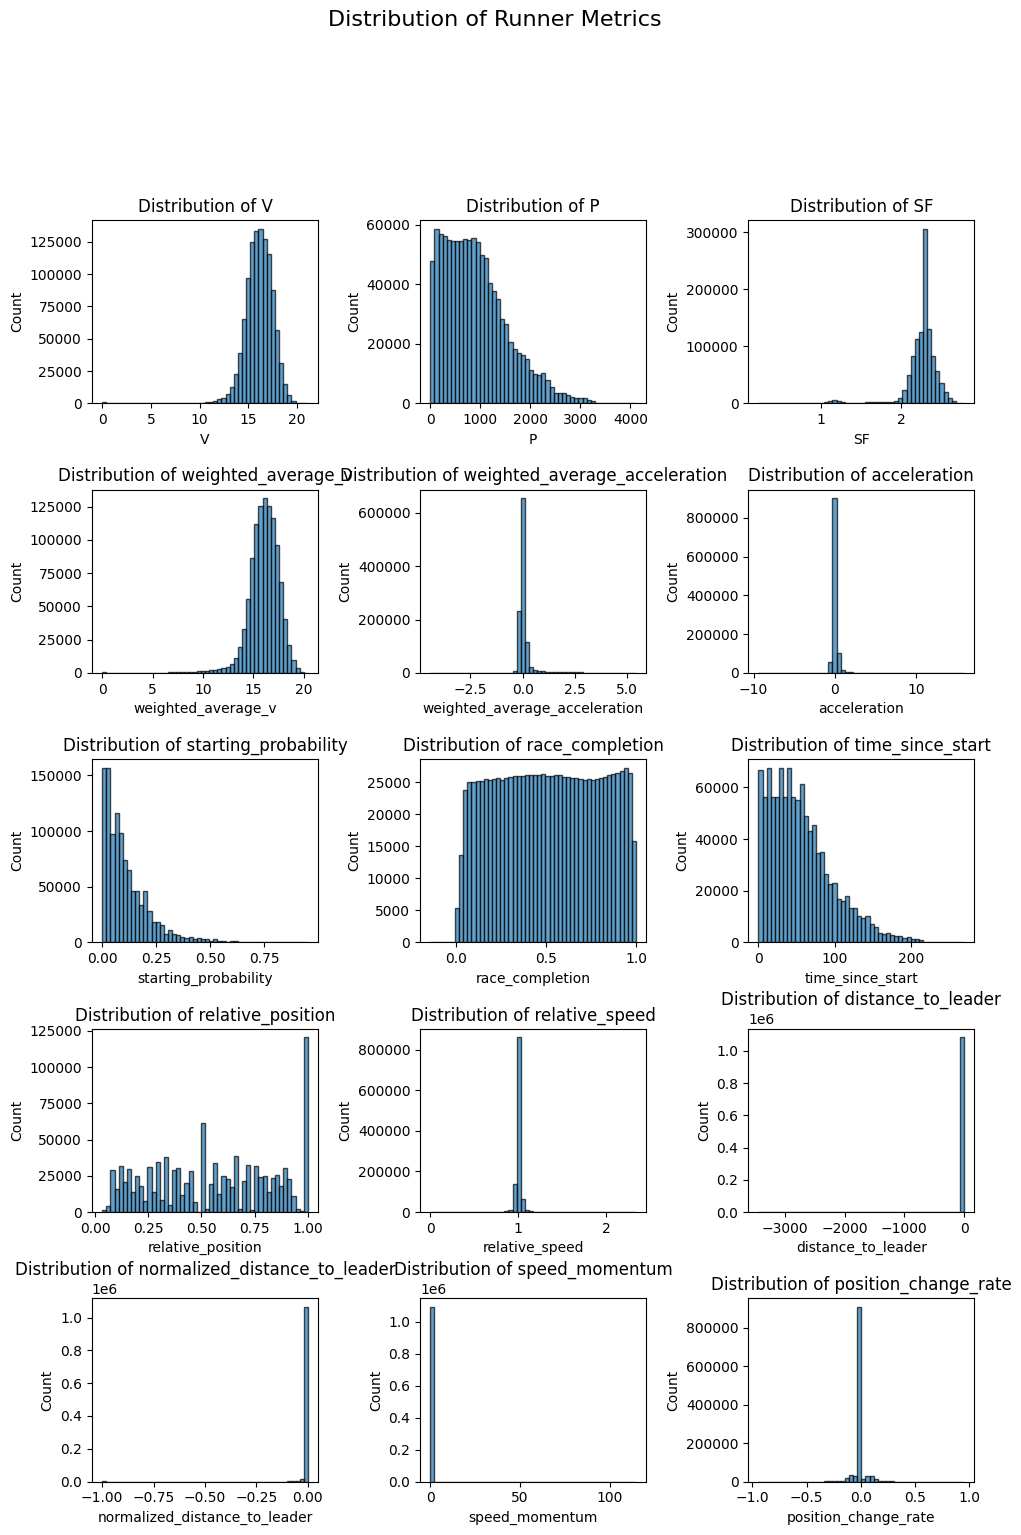

In [13]:
columns_to_plot = selected_features

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    ax.hist(train_df_N[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.suptitle("Distribution of Runner Metrics", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.88)
plt.show()

#### Compute the correlation matrix for the selected numeric columns

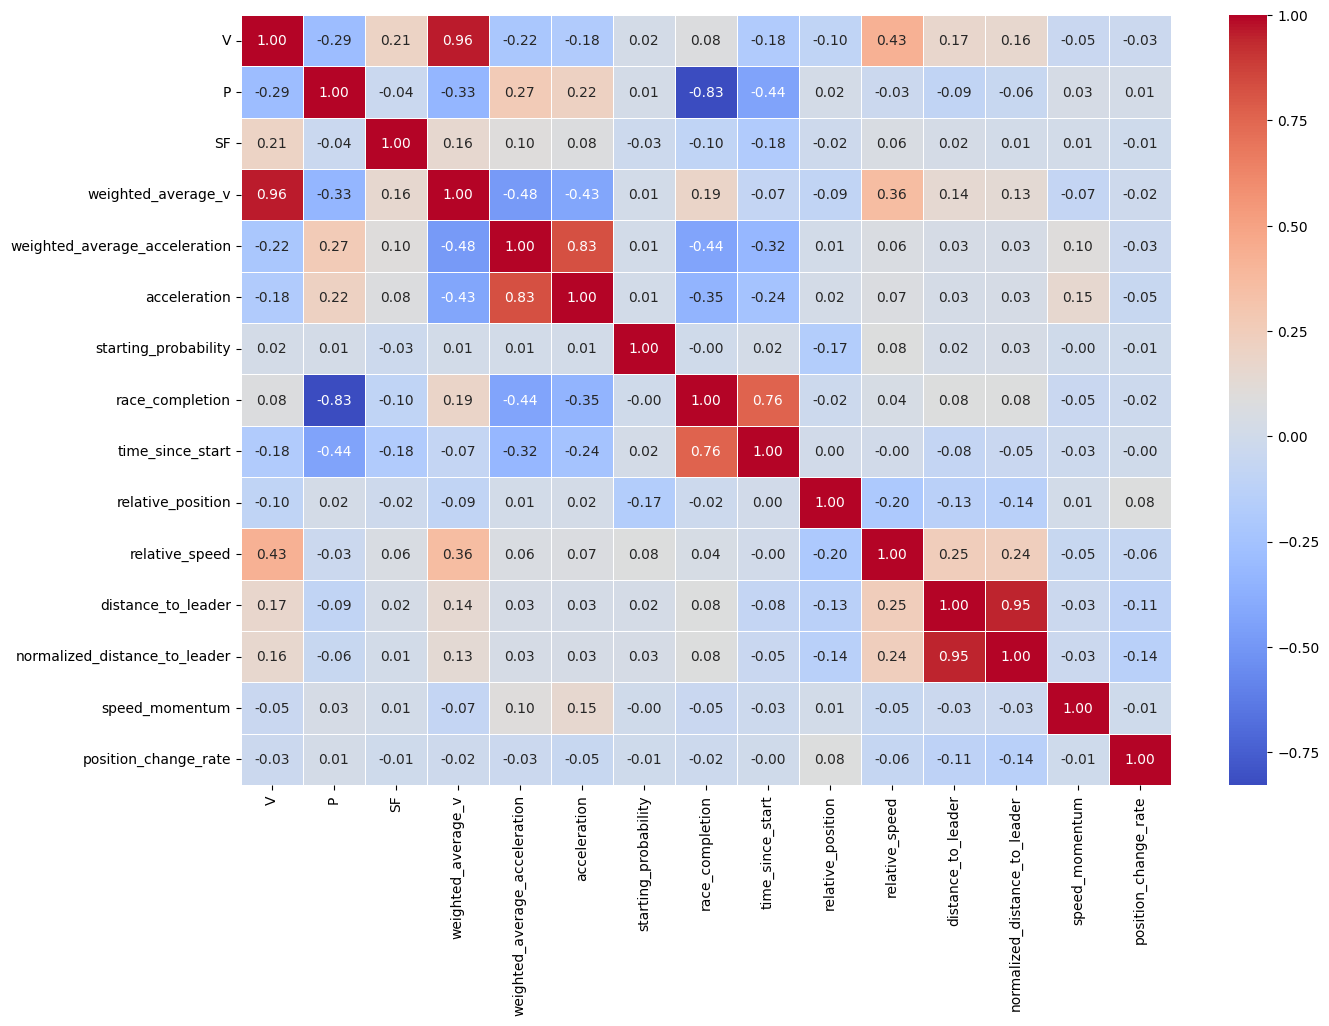

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = train_df_N[selected_features].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [16]:
X = train_df_N.copy()
display(X.columns)
#X = train_df_N[selected_features].copy()
y = train_df['result']

# Handle categorical columns (One-hot encode any categorical columns)
X = pd.get_dummies(X)  

# Convert any True/False into 1/0
#X = X.astype('int64')

display(X)

Index(['V', 'P', 'SF', 'start_timestamp', 'timestamp', 'timestamp_float',
       'weighted_average_v', 'weighted_average_sf', 'weighted_average_v_t-1',
       'previous_instantaneous_v', 'weighted_average_acceleration',
       'acceleration', 'gmax_racecourse_name', 'gmax_country_code',
       'gmax_race_length', 'gmax_racetype_label', 'surface',
       'pa_race_type_string', 'pa_price_prob', 'starting_probability',
       'inplay', 'race_completion', 'time_since_start', 'relative_position',
       'relative_speed', 'distance_to_leader', 'normalized_distance_to_leader',
       'speed_momentum', 'position_change_rate'],
      dtype='object')

,V,P,SF,start_timestamp,timestamp,timestamp_float,weighted_average_v,weighted_average_sf,weighted_average_v_t-1,previous_instantaneous_v,...,gmax_racetype_label_York 1M5f188y Flat,gmax_racetype_label_York 2M56y Flat,gmax_racetype_label_York 5f Flat,gmax_racetype_label_York 5f89y Flat,gmax_racetype_label_York 6f Flat,gmax_racetype_label_York 7f Flat,gmax_racetype_label_York 7f192y Flat,surface_AW,surface_Turf,pa_race_type_string_Flat
7182,13.85,1170.5,2.45,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:10+00:00,1.686924e+09,10.432667,2.254000,7.608000,12.03,...,False,False,False,False,False,False,False,False,True,True
7183,14.65,1153.8,2.42,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:11+00:00,1.686924e+09,12.600667,2.254000,10.432667,13.85,...,False,False,False,False,False,False,False,False,True,True
7184,16.07,1136.2,2.41,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:12+00:00,1.686924e+09,14.292667,2.254000,12.600667,14.65,...,False,False,False,False,False,False,False,False,True,True
7185,16.48,1118.2,2.47,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:13+00:00,1.686924e+09,15.357333,2.254000,14.292667,16.07,...,False,False,False,False,False,False,False,False,True,True
7186,17.34,1099.7,2.51,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:14+00:00,1.686924e+09,16.265333,2.254000,15.357333,16.48,...,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4633568,16.29,72.7,2.12,2023-07-01 13:10:56.720000+00:00,2023-07-01 13:13:24+00:00,1.688217e+09,16.339333,2.130909,16.382667,16.33,...,False,False,False,False,False,False,False,False,True,True
4633569,16.28,56.5,2.13,2023-07-01 13:10:56.720000+00:00,2023-07-01 13:13:25+00:00,1.688217e+09,16.307333,2.129455,16.339333,16.29,...,False,False,False,False,False,False,False,False,True,True
4633570,15.94,40.6,2.06,2023-07-01 13:10:56.720000+00:00,2023-07-01 13:13:26+00:00,1.688217e+09,16.180000,2.116000,16.307333,16.28,...,False,False,False,False,False,False,False,False,True,True
4633571,15.84,25.1,2.08,2023-07-01 13:10:56.720000+00:00,2023-07-01 13:13:27+00:00,1.688217e+09,16.047333,2.108182,16.180000,15.94,...,False,False,False,False,False,False,False,False,True,True


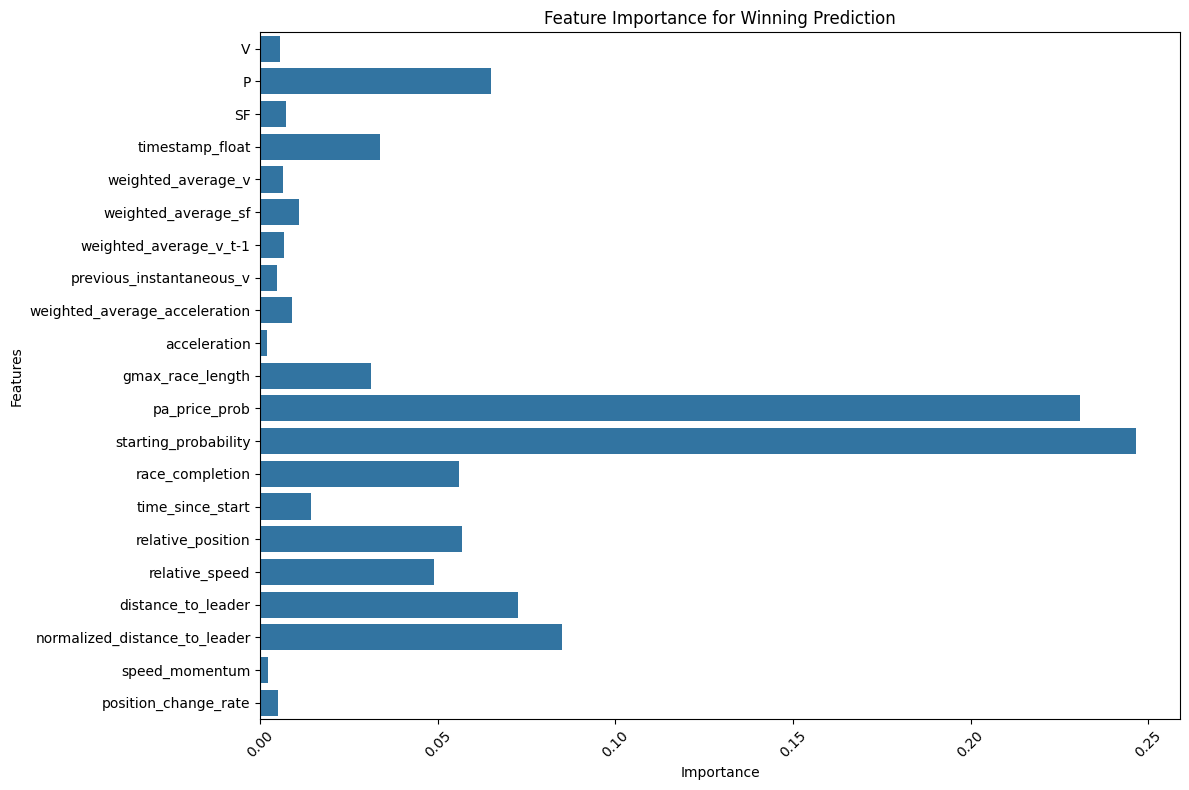

In [17]:
# Remove non-numeric columns 
X = X.select_dtypes(include=[np.number])

# Train a Random Forest model
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42,  n_jobs=-1)

#model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x=model.feature_importances_, y=X.columns)
plt.title('Feature Importance for Winning Prediction')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Check class distribution

In [18]:
# Check full distribution of result
class_counts = train_df['result'].value_counts()

# Display full counts
display(class_counts)

# Access counts individually
false_count = class_counts.get(False, 0)
true_count = class_counts.get(True, 0)

display(f"Complete rows for result = False: {false_count}")
display(f"Complete rows for result = True: {true_count}")

# Now print the ratio (True / False)
if false_count > 0:  # Avoid division by zero
    ratio = true_count / false_count
    display(f"Ratio (True : False) = {ratio:.4f}")
else:
    display("No False cases found to calculate the ratio.")

result
False    969793
True     122462
Name: count, dtype: int64

'Complete rows for result = False: 969793'

'Complete rows for result = True: 122462'

'Ratio (True : False) = 0.1263'

# Part  5 - Winner Prediction 
### Step 1 : Splitting the dataset into the Training set and Test set

In [19]:
from sklearn.model_selection import train_test_split

# Create a new DataFrame with only the selected features
X_train = train_df_N[selected_features]
X_test = test_df_N[selected_features]

# Your label (target to predict) is 'result'
y_train = train_df['result'].astype(int)
y_test = test_df['result'].astype(int)

In [20]:
display(y_train,y_test)

7182       0
7183       0
7184       0
7185       0
7186       0
          ..
4633568    1
4633569    1
4633570    1
4633571    1
4633572    1
Name: result, Length: 1092255, dtype: int32

1858       0
1859       0
1860       0
1861       0
1862       0
          ..
1629115    0
1629116    0
1629117    0
1629118    0
1629119    0
Name: result, Length: 349470, dtype: int32

In [21]:
# Check features
assert not X_train.isnull().any().any(), "X_train contains NaNs"
assert not X_test.isnull().any().any(), "X_test contains NaNs"

# Check labels
assert not y_train.isnull().any(), "y_train contains NaNs"
assert not y_test.isnull().any(), "y_test contains NaNs"

assert set(y_train.unique()).issubset({0, 1}), "Unexpected values in y_train"
assert set(y_test.unique()).issubset({0, 1}), "Unexpected values in y_train"

#### Part 1 : Winner Prediction with Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#### Step 2 : Initializing the Random Forest

In [23]:
rf = RandomForestClassifier(random_state=2024,n_jobs=-1)  

#### Step 3 : Training the Random Forest

In [24]:
from sklearn.model_selection import GridSearchCV

#param_grid = { 
#    'n_estimators': [100, 200, 500],
#    'max_features': ['sqrt', 'log2', None],  
#    'max_depth': [10, 20, 30],
#    'criterion': ['gini', 'entropy'],
#    'min_samples_split': [5, 10],
#    'min_samples_leaf': [5, 10],
#    'bootstrap': [True, False]}

param_grid = {
    'n_estimators': [100, 200],         
    'max_depth': [10, 30],              
    'min_samples_leaf': [5]             
}

CV_rfc = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, verbose=1, n_jobs=-1)
CV_rfc.fit(X_train, y_train)

display("Best Parameters:", CV_rfc.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


'Best Parameters:'

{'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}

#### Feed with the best_params

In [25]:
rf_final=RandomForestClassifier(
    bootstrap=True,
    criterion='gini',
    max_depth=10, 
    max_features='sqrt',
    min_samples_leaf=5,
    min_samples_split = 5,
    n_estimators= 100, 
    random_state=2024,
    n_jobs=-1)

rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=5,
                       n_jobs=-1, random_state=2024)

### Part 2 - Winner Prediction with XGBoost
### Step 1 : Initialize XGBoost Classifier

In [26]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

#### Step 2 : Training the XGB
#### Training the XGB on the Training set Perform Grid Search to find the best_params

In [27]:
from sklearn.model_selection import GridSearchCV
#param_grid = {
#    'max_depth': [3, 5, 7, 9],  # Controls complexity. Higher can overfit.
#    'min_child_weight': [1, 3, 5, 10],  # Higher prevents overfitting.
#    'gamma': [0, 0.2, 0.5, 1],  # Minimum loss reduction required for split.
#    'subsample': [0.6, 0.8, 1.0],  # Fraction of training used per tree.
#    'colsample_bytree': [0.6, 0.8, 1.0],  # Fraction of features used per tree.
#    'scale_pos_weight': [1, 3, 5, 10],  # Key for imbalance; try 10 = #neg/#pos.
#    'learning_rate': [0.01, 0.05, 0.1],  # Smaller values may perform better.
#    'n_estimators': [100, 200],  # # trees. More if learning_rate is small.
#}

param_grid_reduced = {
    'max_depth': [3, 5, 7],  # Keep shallow and medium depths
    'min_child_weight': [1, 5],  # Enough to control overfitting
    'gamma': [0, 0.2],  # Reduce options
    'subsample': [0.8],  # Fix to a good mid-value
    'colsample_bytree': [0.8],  # Fix to reduce search space
    'scale_pos_weight': [1, 5],  # Imbalance control
    'learning_rate': [0.05, 0.1],  # Reasonable range
    'n_estimators': [100]  # Keep fixed for now; tune later with early stopping
}

CV_xgb_model = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
CV_xgb_model.fit(X_train, y_train)

print("Best Parameters:", CV_xgb_model.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


C:\Users\sparv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [19:27:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}


#### Feed with the best_params

In [28]:
xgb_model_final = xgb.XGBClassifier(
    colsample_bytree=1.0, 
    gamma=1, 
    max_depth=10,
    min_child_weight=1, 
    subsample=1.0,
    n_estimators = 100, 
    random_state=2024)

xgb_model_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

### Part 3 - Winner Prediction with Building the ANN
#### Step 2 : Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_Ann = sc.fit_transform(X_train)
X_test_Ann = sc.transform(X_test)

In [30]:
assert not X_train.isnull().any().any()
assert not X_test.isnull().any().any()

### Step 4 : Training the ANN
### Compiling the ANN
### Training the ANN on the Training set

In [49]:
def create_improved_model(input_shape, learning_rate=0.01):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),        
        tf.keras.layers.Dense(128),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Dense(64),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(32),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    # Use a fixed learning rate so ReduceLROnPlateau can adjust it
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model


In [50]:
def train_model(X_train, y_train, X_val, y_val, batch_size=32, max_epochs=100):
    class_weight_dict = {0: 1.0, 1: 1.0}

    model = create_improved_model((X_train.shape[1],))  # Now uses fixed learning rate

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=10,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            mode='min',
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            save_best_only=True,
            monitor='val_auc',
            mode='max',
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
        class_weight=class_weight_dict
    )

    return model, history


In [51]:
# Function to find optimal batch size
def find_optimal_batch_size(X_train, y_train, batch_sizes=[16, 32, 64, 128, 256]):
    """
    Find the optimal batch size by training with different batch sizes
    """
    results = []
    
    for batch_size in batch_sizes:
        print(f"\nTesting batch size: {batch_size}")
        model = create_improved_model((X_train.shape[1],))
        
        # Train for a few epochs to evaluate performance
        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=5,
            batch_size=batch_size,
            verbose=1
        )
        
        # Store results
        results.append({
            'batch_size': batch_size,
            'val_loss': min(history.history['val_loss']),
            'val_accuracy': max(history.history['val_accuracy'])
        })
    
    return pd.DataFrame(results)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

def main_training_process(X, y):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    #batch_size_results = find_optimal_batch_size(X_train, y_train)
    #optimal_batch_size = batch_size_results.loc[
    #    batch_size_results['val_loss'].idxmin(), 'batch_size']

    optimal_batch_size = 256
    
    print(f"\nOptimal batch size: {optimal_batch_size}")
    
    model, history = train_model(
        X_train, y_train,
        X_val, y_val,
        batch_size=optimal_batch_size,
        max_epochs=100
    )
    
    gb_model = GradientBoostingClassifier(
        n_estimators=100,  # Reduced trees
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    
    gb_model.fit(X_train, y_train)

    return model,gb_model, history

In [64]:
# Train the model
ann,gb_model,history = main_training_process(X_train_Ann, y_train)

# Evaluate on test set
test_loss, test_accuracy , test_auc = ann.evaluate(X_test_Ann, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")


Optimal batch size: 256
Epoch 1/100
3399/3414 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8892 - auc: 0.7971 - loss: 0.2913
Epoch 1: val_auc improved from -inf to 0.82884, saving model to best_model.keras
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8893 - auc: 0.7972 - loss: 0.2913 - val_accuracy: 0.8961 - val_auc: 0.8288 - val_loss: 0.2715 - learning_rate: 0.0100
Epoch 2/100
3406/3414 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8936 - auc: 0.8213 - loss: 0.2766
Epoch 2: val_auc improved from 0.82884 to 0.83259, saving model to best_model.keras
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8936 - auc: 0.8213 - loss: 0.2766 - val_accuracy: 0.8953 - val_auc: 0.8326 - val_loss: 0.2701 - learning_rate: 0.0100
Epoch 3/100
3399/3414 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8944 - auc: 0.8248 - loss: 0.2740
Epoch 3: val_auc improved from 0.83259 to 0.83443, saving model to best_model.keras
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8944 - 

Selected metrics: ['accuracy', 'auc', 'loss']


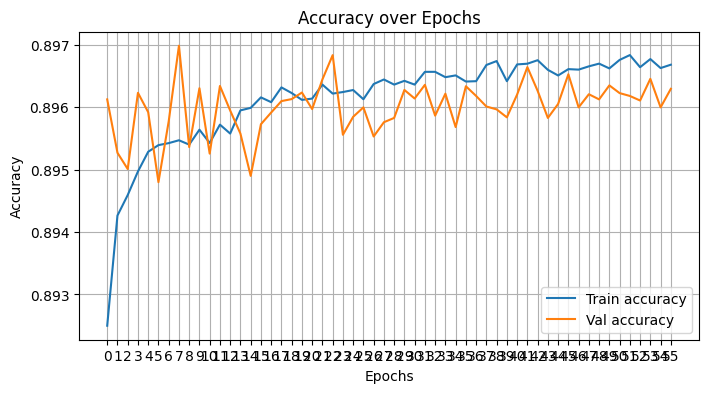

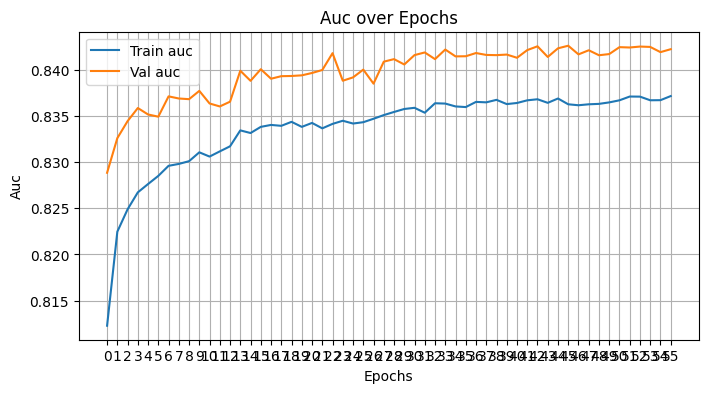

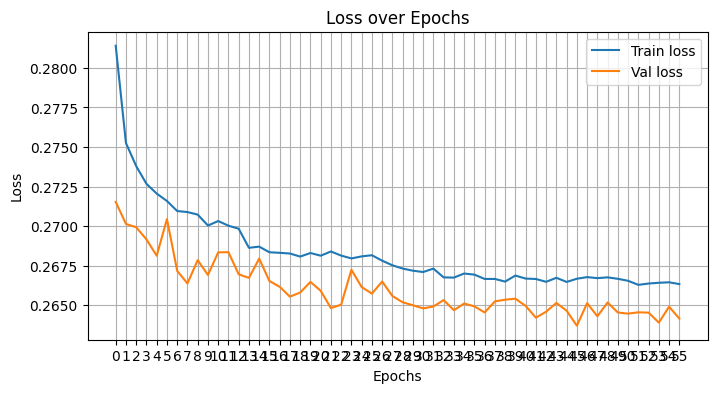

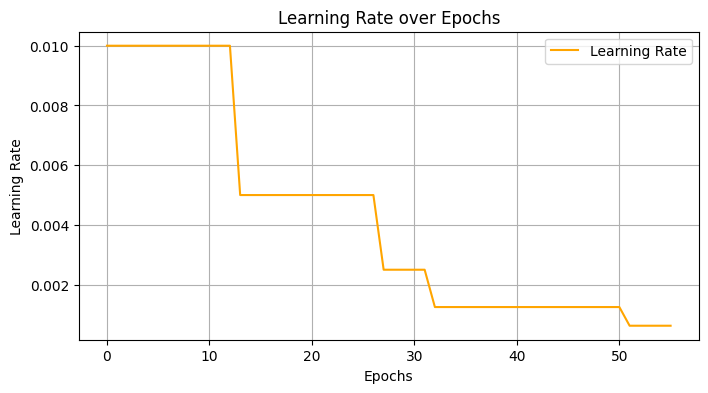

In [65]:
metrics = []
for key in history.history.keys():
    if not key.startswith('val_') and key != 'learning_rate':
        metrics.append(key)

metrics = sorted(metrics)  # optional: sorted for consistent order
print("Selected metrics:", metrics)

def plot_training_history(history):
    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.plot(history.history[metric], label=f'Train {metric}')
        
        val_metric_key = f'val_{metric}'
        if val_metric_key in history.history:
            plt.plot(history.history[val_metric_key], label=f'Val {metric}')
        
        plt.title(f'{metric.capitalize()} over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.xticks(range(len(history.history[metric])))  # optional
        plt.show()

    # Optional: plot learning rate
    if 'learning_rate' in history.history:
        plt.figure(figsize=(8, 4))
        plt.plot(history.history['learning_rate'], label='Learning Rate', color='orange')
        plt.title('Learning Rate over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Learning Rate')
        plt.grid(True)
        plt.legend()
        plt.show()

plot_training_history(history)


### Step 5 : Making the predictions and evaluating the model
### Predicting the result of a single observation

In [ ]:
# keras model template - feel free to use other things

class FlatModel(keras.Model):
    NAME = "flat_model"
    def __init__(self,
                 units: int = 32,
                 name: str = None,
                 **kwargs
                 ):
        name = name or self.NAME
        super().__init__(name = name)

        # define trainable layers

    def get_config(self):
        config = super().get_config()
        return config

    def call(self, inputs: list, training: bool = False) -> tf.Variable:
        """
        if the timeline inputs format is being used.

        gmax_race_length                    # (N, 1)
        surface                             # (N, 1)
        distance_remaining                  # (N, timesteps)
        speed                               # (N, timesteps)
        acceleration                        # (N, timesteps)
        stride_frequency                    # (N, timesteps)
        weighted_average_speed              # (N, timesteps)
        weighted_average_acceleration       # (N, timesteps)
        weighted_average_stride_frequency   # (N, timesteps)
        starting_probability                # (N, 1)
        """
        if isinstance(inputs, dict):
            race_length = inputs["gmax_race_length"]
            surface = inputs["surface"]
            distance_remaining = inputs["distance_remaining"]
            instant_speed = inputs["speed"]
            instant_acceleration = inputs["acceleration"]
            instant_stride_frequency = inputs["stride_frequency"]
            weighted_average_speed = inputs["weighted_average_speed"]
            weighted_average_acceleration = inputs["weighted_average_acceleration"]
            weighted_average_stride_frequency = inputs["weighted_average_stride_frequency"]
            starting_probability = inputs["starting_probabilities"]
        elif isinstance(inputs, list):
            (
            race_length,
            surface,
            distance_remaining,
            instant_speed,
            instant_acceleration,
            instant_stride_frequency,
            weighted_average_speed,
            weighted_average_acceleration,
            weighted_average_stride_frequency,
            starting_probability
            ) = inputs
        
        # complete model call method here

        return starting_probability



In [ ]:
# create model predictions
for (race_id, timestamp), grp in test_df.groupby(["race_id", "timestamp"]):
    pass
    #test_df.loc[grp.index, "prob_model"] = ...

In [66]:
# Function to create ensemble predictions
def create_ensemble_predictions(model_list, X, weights=None):
    """Create ensemble predictions from multiple models"""
    all_preds = []
    
    for model in model_list:
        if isinstance(model, tf.keras.Model):
            preds = model.predict(X).flatten()
        else:
            preds = model.predict_proba(X)[:, 1]
        all_preds.append(preds)
    
    # Default to equal weights if not provided
    if weights is None:
        weights = [1/len(model_list)] * len(model_list)
    
    # Weighted average
    ensemble_preds = np.zeros_like(all_preds[0])
    for i, preds in enumerate(all_preds):
        ensemble_preds += weights[i] * preds
    
    return ensemble_preds

In [ ]:
y_pred_ann = ann.predict(X_test_Ann).flatten()
y_pred_gb = gb_model.predict_proba(X_test_Ann)[:, 1]
y_pred_xgb = xgb_model_final.predict_proba(X_test)[:, 1]
y_pred_RF = rf_final.predict_proba(X_test)[:, 1]
y_pred_ST = test_df.starting_probability.copy()

# ANN predictions
test_df = test_df.assign(
    prob_model_ann = create_ensemble_predictions(
        [ann, gb_model], 
        X_test_Ann, 
        weights=[0.6, 0.4]  
    ),
)

# XGBoost predictions
test_df = test_df.assign(
     prob_model_xgb = y_pred_xgb,
 )

# Random forest
test_df = test_df.assign(
     prob_model_RF = y_pred_RF,
 )

# For baseline comparison (starting probability)
test_df = test_df.assign(
    prob_starting_probability = y_pred_ST,
)

10921/10921 ━━━━━━━━━━━━━━━━━━━━ 9s 841us/step
10921/10921 ━━━━━━━━━━━━━━━━━━━━ 9s 819us/step


In [ ]:
# evaluation functions

def compute_r2(probabilities: np.ndarray,
               result: np.ndarray
               ) -> float:
    """
    r2 score as detailed in the Benter hong kong paper.
    scores close to 1 imply a very good model.
    """
    # dead heats not allowed, maybe adapt later to allow it
    probabilities = probabilities / np.sum(probabilities)
    winner_probability = probabilities[result == 1.][0]
    p_baseline = np.mean(probabilities)
    if p_baseline == 1:
        p_baseline = 0.9999
    r2_score = 1 - ((1 - winner_probability) ** 2) / ((1 - p_baseline) ** 2)
    return r2_score

for name, grp in tqdm(test_df.groupby(["race_id", "timestamp"])):
    result = grp.pa_finish_position.to_numpy().reshape(-1) == 1
    if not np.any(result):
        test_df.loc[grp.index, "r2_score_exchange"] = np.nan
        test_df.loc[grp.index, "r2_score_starting_pro"] = np.nan
        test_df.loc[grp.index, "r2_score_ann"] = np.nan
        test_df.loc[grp.index, "r2_score_xgb"] = np.nan
        test_df.loc[grp.index, "r2_score_RF"] = np.nan
        continue
    test_df.loc[grp.index, "r2_score_exchange"] = compute_r2(grp["prob_exchange"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_starting_pro"] = compute_r2(grp["prob_starting_probability"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_ann"] = compute_r2(grp["prob_model_ann"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_xgb"] = compute_r2(grp["prob_model_xgb"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_RF"] = compute_r2(grp["prob_model_RF"].to_numpy().reshape(-1), result)

In [69]:
def plot_r2_scores(df: pd.DataFrame):
    distance_bounds = [
        10000, 1200, 1100, 1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 0
        ]

    model_data = []
    exchange_data = []
    ann_data = []
    xgb_data = []
    RF_data = []

    for upper, lower in zip(distance_bounds, distance_bounds[1:]):
        grp = df[df.P.between(lower, upper)]
        # get unique [race_id, timestamp] r2 scores
        ann_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_ann"].mean()
        )
        xgb_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_xgb"].mean()
        )
        RF_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_RF"].mean()            
        )
        model_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_starting_pro"].mean()
        )
        exchange_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_exchange"].mean()
        )

    fig = go.Figure()
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = ann_data,
            name = " ANN Model",
            marker_color = "blue"
            )
    )
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = xgb_data,
            name = " XGB Model",
            marker_color = "purple"
            )
    )            
    fig.add_trace(
            go.Bar(
                x = distance_bounds[1:],
                y = RF_data,
                name = " RF Model",
                marker_color = "green"
                )            
    )
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = model_data,
            name = " Starting Pro Model",
            marker_color = "red"
            )
    )
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = exchange_data,
            name = "Exchange",
            marker_color = "gold"
            )
    )
    fig.update_layout(
        title = "R2 predictive power scores. Higher is better",
        xaxis_title = "Distance Remaining",
        yaxis_title = "R2 score",
    )
    fig.show()


ALL_COLOURS = {
    "01": "red",
    "02": "blue",
    "03": "silver",
    "04": "forestgreen",
    "05": "black",
    "06": "yellow",
    "07": "magenta",
    "08": "grey",
    "09": "purple",
    "10": "orange",
    "11": "olivedrab",
    "12": "darksalmon",
    "13": "darkred",
    "14": "saddlebrown",
    "15": "navy",
    "16": "chartreuse",
    "1A": "palevioletred",
    "2B": "turquoise"
}

def plot_predictions(df: pd.DataFrame) -> None:
    """
    group by runners and plot each runner prediction timeline
    """
    placers = df[df.pa_finish_position < 4].runner_id.unique().tolist()
    winners = df[df.pa_finish_position == 1].runner_id.unique().tolist()
    if df.empty:
        return
    fig = go.Figure()
    colours = iter(ALL_COLOURS.values())
    for runner_id, runner in df.groupby("runner_id"):
        colour = next(colours)
        fig.add_trace(
            go.Scatter(
                x = runner.timestamp,
                y = runner["prob_model"],
                mode = "lines+markers",
                name = f"{runner_id} - Model Prob",
                marker = {
                    "color": colour,
                    "size": 4
                },
                line = {
                    "color": colour,
                    "width": 3,
                    "dash": "solid"
                },
                opacity = 0.9,
                visible = "legendonly" if runner_id not in placers else None
            )
        )

        fig.add_trace(
            go.Scatter(
                x = runner.timestamp,
                y = 1. / runner["prob_exchange"],
                mode = "lines+markers",
                name = "{0} - {1}".format("Exchange prob", runner_id),
                marker = {
                    "color": colour,
                    "size": 3.5
                },
                line = {
                    "color": colour,
                    "width": 3,
                    "dash": "dot"
                },
                opacity = 0.65,
                visible = "legendonly" if runner_id not in placers else None
            )
        )
    fig.update_layout(
        title = "Timeline of model predictions - {0}, Winner: {2}".format(df.race_id.iloc[0], winners),
        xaxis_title = "Timeline",
        yaxis_title = "Probability",
        showlegend = True
    )
    fig.show()

In [70]:
plot_r2_scores(test_df)

#### Evaluate All Your Models

In [71]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# True labels
y_true = y_test  

# Initialize a dictionary to store metrics
results = {}

def evaluate_model(y_true, y_pred_proba, threshold=0.5):
    y_pred_binary = (y_pred_proba >= threshold).astype(int)  # Convert probabilities to 0/1
    return {
        "ROC-AUC": roc_auc_score(y_true, y_pred_proba),
        "Accuracy": accuracy_score(y_true, y_pred_binary),
        "Precision": precision_score(y_true, y_pred_binary),
        "Recall": recall_score(y_true, y_pred_binary),
        "F1-Score": f1_score(y_true, y_pred_binary)
    }

# Evaluate each model
results['ANN'] = evaluate_model(y_true, y_pred_ann)
results['XGBoost'] = evaluate_model(y_true, y_pred_xgb)
results['RandomForest'] = evaluate_model(y_true, y_pred_RF)
results['StartingProbability (baseline)'] = evaluate_model(y_true, y_pred_ST)

results_df = pd.DataFrame(results).T
print(results_df.round(4))


                                ROC-AUC  Accuracy  Precision  Recall  F1-Score
ANN                              0.8289    0.8938     0.6797  0.1006    0.1752
XGBoost                          0.7917    0.8826     0.4492  0.2072    0.2836
RandomForest                     0.8300    0.8963     0.6716  0.1474    0.2418
StartingProbability (baseline)   0.7813    0.8878     0.4986  0.0499    0.0907


❗ Recall and F1-Score are very low, meaning models are not catching the positive (win) cases well.